## 1. Setup


In [1]:
import os
import json
import time
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Using CPU (training will be slower)")

print(f"PyTorch version: {torch.__version__}")


Using GPU: NVIDIA GeForce RTX 3070
PyTorch version: 2.11.0+cu128


In [2]:
RUNS_DIR = Path("runs")
RUNS_DIR.mkdir(exist_ok=True)


class RunLogger:
    """Manages a single training run: folder, config, history, checkpoints."""

    def __init__(self, name: str, config: dict):
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.run_id = f"{name}_{timestamp}"
        self.dir = RUNS_DIR / self.run_id
        self.dir.mkdir(parents=True, exist_ok=True)

        self.config = config
        self.history = {"train_loss": [], "train_acc": [],
                        "test_loss": [], "test_acc": [],
                        "epoch_time_sec": []}
        self.best_test_loss = float("inf")
        self.start_time = time.time()

        # Persist the config immediately
        with open(self.dir / "config.json", "w") as f:
            json.dump(config, f, indent=2)

        print(f"[RunLogger] New run: {self.run_id}")

    def log_epoch(self, epoch, train_loss, train_acc, test_loss, test_acc, epoch_time):
        self.history["train_loss"].append(train_loss)
        self.history["train_acc"].append(train_acc)
        self.history["test_loss"].append(test_loss)
        self.history["test_acc"].append(test_acc)
        self.history["epoch_time_sec"].append(epoch_time)

        # Always write history after each epoch (resumable / inspectable)
        with open(self.dir / "history.json", "w") as f:
            json.dump(self.history, f, indent=2)

    def save_checkpoint(self, model, epoch, tag=None):
        """Save model weights. Use tag like 'best' or 'epoch_05'."""
        name = f"{tag}.pt" if tag else f"epoch_{epoch:02d}.pt"
        torch.save(model.state_dict(), self.dir / name)

    def maybe_save_best(self, model, test_loss, epoch):
        """Save the model if it beats the previous best test loss."""
        if test_loss < self.best_test_loss:
            self.best_test_loss = test_loss
            self.save_checkpoint(model, epoch, tag="best")
            return True
        return False

    def total_time(self):
        return time.time() - self.start_time


In [3]:
class AddGaussianNoise:
    """Custom transform: adds Gaussian noise to a tensor image."""
    def __init__(self, mean=0.0, std=0.05):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std + self.mean


# Training: with augmentation
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    AddGaussianNoise(mean=0.0, std=0.05),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# Test: no augmentation, just normalise
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=train_transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=test_transform)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")


Training samples: 60000
Test samples:     10000


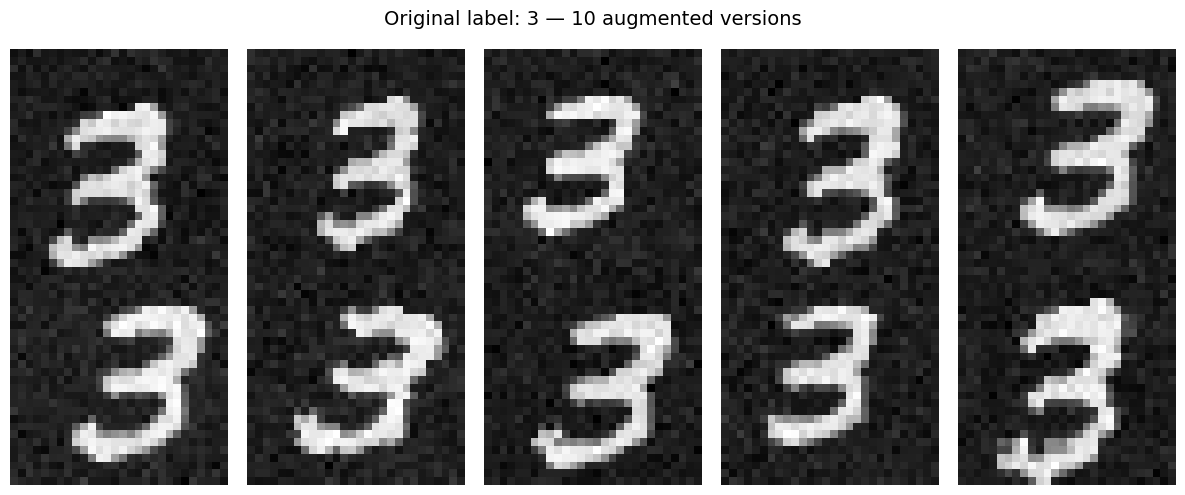

In [4]:
# Take one digit and apply the train transform 10 times
raw_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=None)
sample_pil, sample_label = raw_dataset[7]   # pick any index

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax in axes.flat:
    augmented = train_transform(sample_pil)
    # un-normalise for display
    img = augmented.squeeze() * 0.3081 + 0.1307
    ax.imshow(img, cmap="gray")
    ax.axis("off")
fig.suptitle(f"Original label: {sample_label} — 10 augmented versions", fontsize=14)
plt.tight_layout()
plt.show()


### 4a. FFN baseline (same as Part 1, for comparison)

In [5]:
class FFN(nn.Module):
    """Fully-connected feed-forward network — the Part 1 baseline."""

    def __init__(self, hidden1=128, hidden2=64, dropout=0.0):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, 10)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x)


### 4b. Simple CNN — one conv layer

A single conv layer, then flatten into a fully-connected classifier.

In [6]:
class SimpleCNN(nn.Module):
    """One conv layer + FC head."""

    def __init__(self, num_kernels=16, kernel_size=3, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(1, num_kernels, kernel_size=kernel_size, padding=1)
        self.bn1 = nn.BatchNorm2d(num_kernels)
        self.pool = nn.MaxPool2d(2, 2)              # 28 -> 14

        # After conv+pool: (num_kernels, 14, 14)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(num_kernels * 14 * 14, 64)
        self.fc2 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


### 4c. Deeper CNN — two conv layers

Two stacked conv blocks. The first picks up edges and simple strokes; the second composes those into more complex shapes (loops, junctions). After two `(2,2)` poolings the spatial size goes 28 → 14 → 7.

In [7]:
class DeeperCNN(nn.Module):
    """Two conv layers + FC head."""

    def __init__(self, k1=16, k2=32, kernel_size=3, dropout=0.3):
        super().__init__()
        # Block 1
        self.conv1 = nn.Conv2d(1,  k1, kernel_size=kernel_size, padding=1)
        self.bn1   = nn.BatchNorm2d(k1)
        # Block 2
        self.conv2 = nn.Conv2d(k1, k2, kernel_size=kernel_size, padding=1)
        self.bn2   = nn.BatchNorm2d(k2)

        self.pool = nn.MaxPool2d(2, 2)  # used after each block: 28 -> 14 -> 7

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(k2 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # -> (k1, 14, 14)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # -> (k2,  7,  7)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Sanity check param counts (helps when comparing architectures fairly)
for cls, name in [(FFN, "FFN"), (SimpleCNN, "SimpleCNN"), (DeeperCNN, "DeeperCNN")]:
    m = cls()
    print(f"{name:12s}  {count_params(m):>10,}  params")


FFN              109,386  params
SimpleCNN        201,610  params
DeeperCNN        207,018  params


In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, test_loader, config: dict, run_name: str,
                checkpoint_every: int = 5):
    """Full training loop with MLOps logging and checkpointing."""
    model = model.to(device)
    logger = RunLogger(run_name, config)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config.get("weight_decay", 0.0),   # L2 regularisation
    )

    for epoch in range(1, config["epochs"] + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)
        epoch_time = time.time() - t0

        logger.log_epoch(epoch, train_loss, train_acc, test_loss, test_acc, epoch_time)

        # Save best so far (anti-overfitting safety net)
        improved = logger.maybe_save_best(model, test_loss, epoch)

        # Periodic checkpoint
        if epoch % checkpoint_every == 0:
            logger.save_checkpoint(model, epoch)

        flag = " (best)" if improved else ""
        print(f"  Epoch {epoch:2d}/{config['epochs']} | "
              f"train {train_loss:.4f}/{train_acc*100:5.2f}% | "
              f"test {test_loss:.4f}/{test_acc*100:5.2f}% | "
              f"{epoch_time:.1f}s{flag}")

    total = logger.total_time()
    print(f"  Done. Total time: {total:.1f}s. Best test loss: {logger.best_test_loss:.4f}")
    return logger


In [9]:
EPOCHS = 6
LR = 1e-3
WD = 1e-4   # weight decay (L2 regularisation)
DROPOUT = 0.3

base_config = dict(
    epochs=EPOCHS,
    learning_rate=LR,
    weight_decay=WD,
    dropout=DROPOUT,
    batch_size=BATCH_SIZE,
)

results = {}

print("\n=== Training FFN baseline ===")
results["FFN"] = train_model(
    FFN(dropout=DROPOUT),
    train_loader, test_loader,
    {**base_config, "model": "FFN"},
    run_name="ffn_baseline",
)

print("\n=== Training Simple CNN ===")
results["SimpleCNN"] = train_model(
    SimpleCNN(num_kernels=16, dropout=DROPOUT),
    train_loader, test_loader,
    {**base_config, "model": "SimpleCNN", "num_kernels": 16},
    run_name="simple_cnn",
)

print("\n=== Training Deeper CNN ===")
results["DeeperCNN"] = train_model(
    DeeperCNN(k1=16, k2=32, dropout=DROPOUT),
    train_loader, test_loader,
    {**base_config, "model": "DeeperCNN", "k1": 16, "k2": 32},
    run_name="deeper_cnn",
)



=== Training FFN baseline ===
[RunLogger] New run: ffn_baseline_20260501_005433
  Epoch  1/6 | train 0.9398/69.21% | test 0.2190/94.29% | 23.8s (best)
  Epoch  2/6 | train 0.5172/84.02% | test 0.1408/96.06% | 23.0s (best)
  Epoch  3/6 | train 0.4330/86.63% | test 0.1248/96.20% | 24.4s (best)
  Epoch  4/6 | train 0.3944/87.89% | test 0.1163/96.35% | 24.1s (best)
  Epoch  5/6 | train 0.3681/88.75% | test 0.1027/97.02% | 23.4s (best)
  Epoch  6/6 | train 0.3558/89.23% | test 0.0998/96.90% | 23.2s (best)
  Done. Total time: 142.1s. Best test loss: 0.0998

=== Training Simple CNN ===
[RunLogger] New run: simple_cnn_20260501_005655
  Epoch  1/6 | train 0.8774/71.35% | test 0.2049/94.08% | 23.4s (best)
  Epoch  2/6 | train 0.4998/83.91% | test 0.1736/94.67% | 23.6s (best)
  Epoch  3/6 | train 0.4337/86.11% | test 0.0962/97.15% | 23.2s (best)
  Epoch  4/6 | train 0.3936/87.41% | test 0.0925/97.11% | 23.0s (best)
  Epoch  5/6 | train 0.3769/87.90% | test 0.0845/97.35% | 22.8s (best)
  Epoch  6

### Compare runs side-by-side

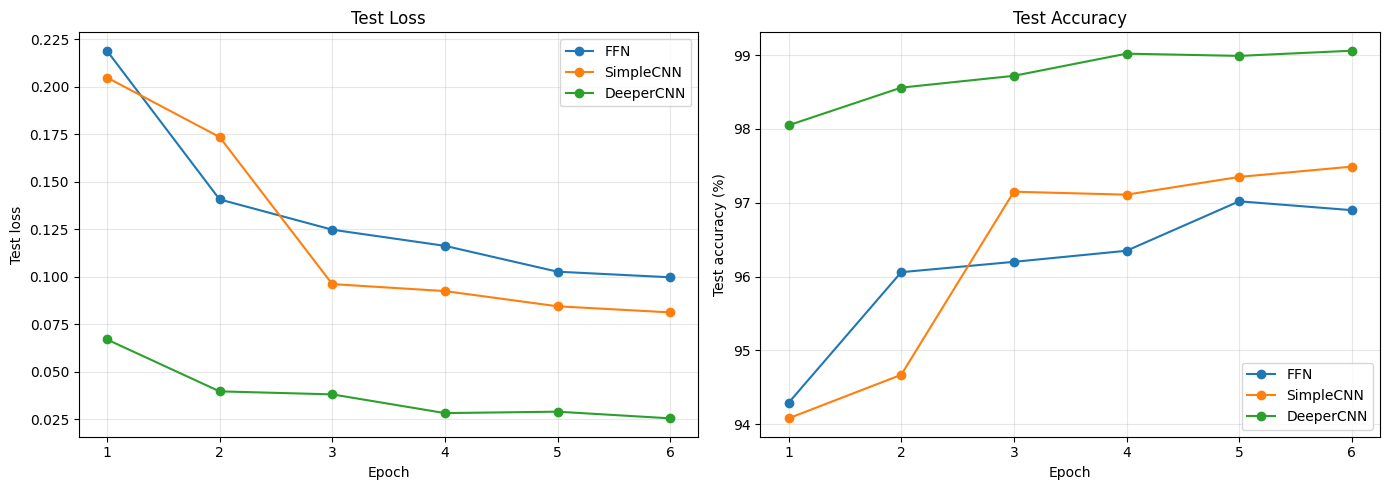


Final numbers:
Model        Best test loss   Final test acc   Total time (s)  
FFN          0.0998           96.90            429.0           
SimpleCNN    0.0813           97.49            286.9           
DeeperCNN    0.0255           99.06            146.5           


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, logger in results.items():
    h = logger.history
    epochs_x = range(1, len(h["test_loss"]) + 1)
    axes[0].plot(epochs_x, h["test_loss"], "o-", label=name)
    axes[1].plot(epochs_x, [a * 100 for a in h["test_acc"]], "o-", label=name)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Test loss"); axes[0].set_title("Test Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Test accuracy (%)"); axes[1].set_title("Test Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFinal numbers:")
print(f"{'Model':<12} {'Best test loss':<16} {'Final test acc':<16} {'Total time (s)':<16}")
for name, logger in results.items():
    final_acc = logger.history["test_acc"][-1] * 100
    print(f"{name:<12} {logger.best_test_loss:<16.4f} {final_acc:<16.2f} {logger.total_time():<16.1f}")


conv1 weights shape: (16, 1, 3, 3)


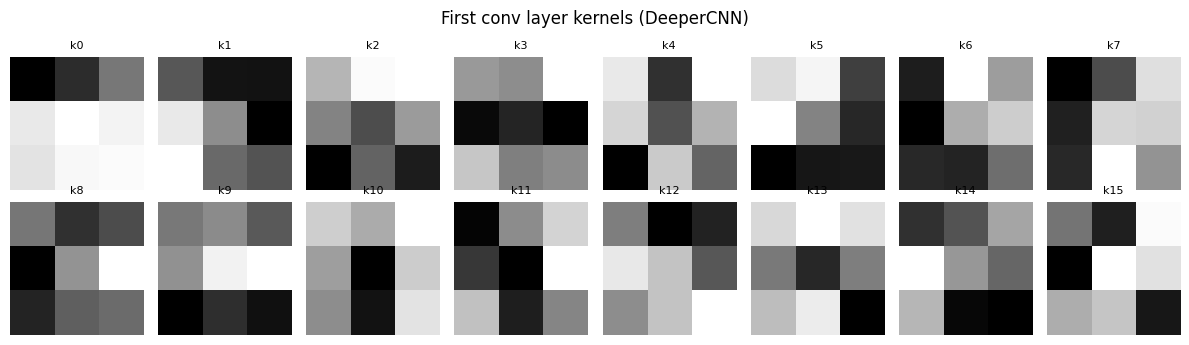

In [11]:
# Reload the *best* DeeperCNN we just trained
deeper_logger = results["DeeperCNN"]
best_path = deeper_logger.dir / "best.pt"

best_deeper = DeeperCNN(k1=16, k2=32, dropout=DROPOUT).to(device)
best_deeper.load_state_dict(torch.load(best_path, map_location=device))
best_deeper.eval()

# Grab conv1 weights: shape (k1, 1, kH, kW)
w1 = best_deeper.conv1.weight.detach().cpu().numpy()
print(f"conv1 weights shape: {w1.shape}")

n_kernels = w1.shape[0]
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i, ax in enumerate(axes.flat):
    if i < n_kernels:
        ax.imshow(w1[i, 0], cmap="gray")
        ax.set_title(f"k{i}", fontsize=8)
    ax.axis("off")
fig.suptitle("First conv layer kernels (DeeperCNN)", fontsize=12)
plt.tight_layout()
plt.show()


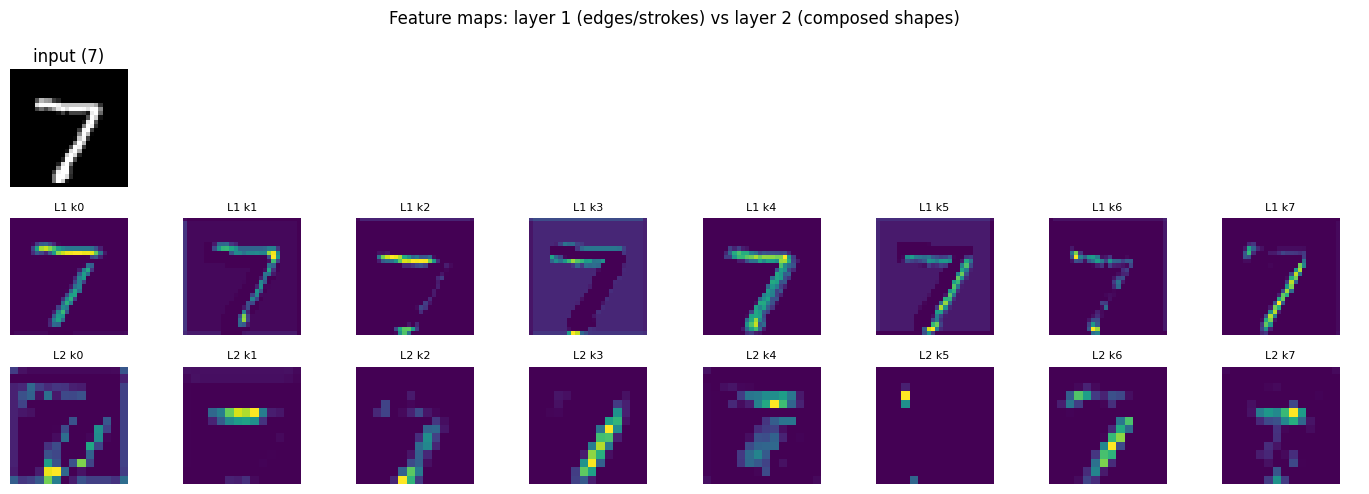

In [12]:
# Pick a clean test digit
sample_img, sample_label = test_dataset[0]
sample_input = sample_img.unsqueeze(0).to(device)   # (1, 1, 28, 28)

with torch.no_grad():
    # First conv block activations
    a1 = F.relu(best_deeper.bn1(best_deeper.conv1(sample_input)))
    # Second conv block activations (after pool of block 1)
    pooled1 = best_deeper.pool(a1)
    a2 = F.relu(best_deeper.bn2(best_deeper.conv2(pooled1)))

a1 = a1.squeeze(0).cpu().numpy()   # (k1, 28, 28)
a2 = a2.squeeze(0).cpu().numpy()   # (k2, 14, 14)

# Plot original + a few feature maps from layer 1 and layer 2
fig, axes = plt.subplots(3, 8, figsize=(14, 5))
axes[0, 0].imshow(sample_img.squeeze() * 0.3081 + 0.1307, cmap="gray")
axes[0, 0].set_title(f"input ({sample_label})")
for j in range(1, 8):
    axes[0, j].axis("off")
axes[0, 0].axis("off")

for j in range(8):
    axes[1, j].imshow(a1[j], cmap="viridis")
    axes[1, j].set_title(f"L1 k{j}", fontsize=8)
    axes[1, j].axis("off")
    axes[2, j].imshow(a2[j], cmap="viridis")
    axes[2, j].set_title(f"L2 k{j}", fontsize=8)
    axes[2, j].axis("off")

fig.suptitle("Feature maps: layer 1 (edges/strokes) vs layer 2 (composed shapes)")
plt.tight_layout()
plt.show()


In [13]:
hp_grid = [
    {"learning_rate": 1e-3, "dropout": 0.3, "weight_decay": 1e-4},
    {"learning_rate": 1e-3, "dropout": 0.5, "weight_decay": 1e-4},
    {"learning_rate": 5e-4, "dropout": 0.3, "weight_decay": 1e-4},
    {"learning_rate": 1e-3, "dropout": 0.3, "weight_decay": 1e-3},
]

HP_EPOCHS = 5  # keep short for the sweep
hp_results = []

for i, hp in enumerate(hp_grid):
    print(f"\n=== HP run {i+1}/{len(hp_grid)}: {hp} ===")
    cfg = {**hp, "epochs": HP_EPOCHS, "model": "DeeperCNN", "k1": 16, "k2": 32,
           "batch_size": BATCH_SIZE}
    model = DeeperCNN(k1=16, k2=32, dropout=hp["dropout"])
    logger = train_model(model, train_loader, test_loader, cfg,
                         run_name=f"hp_run_{i+1}", checkpoint_every=HP_EPOCHS)
    hp_results.append((hp, logger))



=== HP run 1/4: {'learning_rate': 0.001, 'dropout': 0.3, 'weight_decay': 0.0001} ===
[RunLogger] New run: hp_run_1_20260501_010143
  Epoch  1/5 | train 0.3969/87.62% | test 0.0738/97.63% | 25.0s (best)
  Epoch  2/5 | train 0.1607/95.09% | test 0.0407/98.65% | 24.0s (best)
  Epoch  3/5 | train 0.1293/96.05% | test 0.0458/98.47% | 24.5s
  Epoch  4/5 | train 0.1125/96.62% | test 0.0346/98.86% | 24.6s (best)
  Epoch  5/5 | train 0.1027/96.82% | test 0.0278/98.98% | 24.4s (best)
  Done. Total time: 122.6s. Best test loss: 0.0278

=== HP run 2/4: {'learning_rate': 0.001, 'dropout': 0.5, 'weight_decay': 0.0001} ===
[RunLogger] New run: hp_run_2_20260501_010346
  Epoch  1/5 | train 0.5777/81.64% | test 0.0923/97.13% | 25.1s (best)
  Epoch  2/5 | train 0.2530/92.35% | test 0.0557/98.02% | 24.1s (best)
  Epoch  3/5 | train 0.2120/93.52% | test 0.0461/98.28% | 24.4s (best)
  Epoch  4/5 | train 0.1873/94.48% | test 0.0372/98.62% | 24.9s (best)
  Epoch  5/5 | train 0.1660/94.90% | test 0.0349/98.8

### Hyper-parameter sweep summary

In [14]:
print(f"{'#':<3} {'lr':<8} {'dropout':<8} {'wd':<8} {'best_test_loss':<16} {'final_test_acc':<16}")
print("-" * 70)
for i, (hp, logger) in enumerate(hp_results, start=1):
    final_acc = logger.history["test_acc"][-1] * 100
    print(f"{i:<3} {hp['learning_rate']:<8.4f} {hp['dropout']:<8.2f} "
          f"{hp['weight_decay']:<8.4f} {logger.best_test_loss:<16.4f} "
          f"{final_acc:<16.2f}")

# Identify the winner
best_idx = min(range(len(hp_results)), key=lambda i: hp_results[i][1].best_test_loss)
print(f"\nBest configuration: run #{best_idx + 1} -> {hp_results[best_idx][0]}")


#   lr       dropout  wd       best_test_loss   final_test_acc  
----------------------------------------------------------------------
1   0.0010   0.30     0.0001   0.0278           98.98           
2   0.0010   0.50     0.0001   0.0349           98.88           
3   0.0005   0.30     0.0001   0.0353           98.89           
4   0.0010   0.30     0.0010   0.0323           98.96           

Best configuration: run #1 -> {'learning_rate': 0.001, 'dropout': 0.3, 'weight_decay': 0.0001}
